# Restaurant Data Analysis Project

## Introduction
This project analyzes restaurant data to understand customer behavior, spending patterns, and tipping trends using data analysis and visualization techniques.

In [100]:
import pandas as pd

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"
df = pd.read_csv(url)

df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [101]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    object 
 3   smoker      244 non-null    object 
 4   day         244 non-null    object 
 5   time        244 non-null    object 
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), object(4)
memory usage: 13.5+ KB
None
       total_bill         tip        size
count  244.000000  244.000000  244.000000
mean    19.785943    2.998279    2.569672
std      8.902412    1.383638    0.951100
min      3.070000    1.000000    1.000000
25%     13.347500    2.000000    2.000000
50%     17.795000    2.900000    2.000000
75%     24.127500    3.562500    3.000000
max     50.810000   10.000000    6.000000


In [102]:
df['revenue_per_person'] = df['total_bill'] / df['size']

df.head()

,total_bill,tip,sex,smoker,day,time,size,revenue_per_person
0,16.99,1.01,Female,No,Sun,Dinner,2,8.495000
1,10.34,1.66,Male,No,Sun,Dinner,3,3.446667
2,21.01,3.50,Male,No,Sun,Dinner,3,7.003333
3,23.68,3.31,Male,No,Sun,Dinner,2,11.840000
4,24.59,3.61,Female,No,Sun,Dinner,4,6.147500


In [103]:
df.groupby('day')['total_bill'].sum()

,total_bill
day,
Fri,325.88
Sat,1778.40
Sun,1627.16
Thur,1096.33


In [104]:
df.groupby('sex')['tip'].mean()

,tip
sex,
Female,2.833448
Male,3.089618


In [105]:
df.groupby('time')['total_bill'].mean()

,total_bill
time,
Dinner,20.797159
Lunch,17.168676


In [106]:
df.groupby('size')['total_bill'].mean()

,total_bill
size,
1,7.242500
2,16.448013
3,23.277632
4,28.613514
5,30.068000
6,34.830000


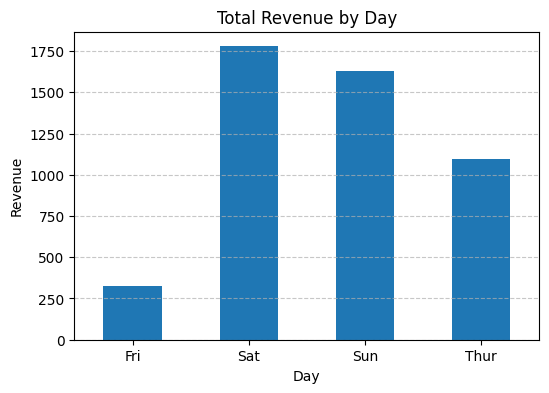

In [107]:
plt.figure(figsize=(6,4))
df.groupby('day')['total_bill'].sum().plot(kind='bar')

plt.title("Total Revenue by Day")
plt.xlabel("Day")
plt.ylabel("Revenue")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

## Insight
The restaurant generates the highest revenue on weekends, particularly on Saturday and Sunday, while weekdays like Friday show comparatively lower revenue. This suggests that customer turnout is significantly higher during weekends.


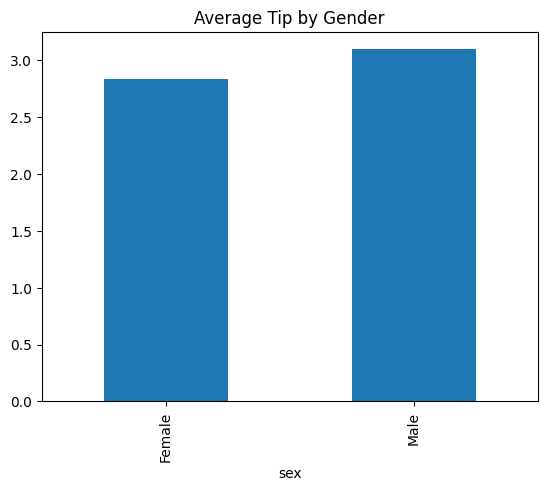

In [108]:
df.groupby('sex')['tip'].mean().plot(kind='bar')
plt.title("Average Tip by Gender")
plt.show()

## Insight
On average, tips linked to male customers appear higher than those for female customers. However, this difference may be influenced by other variables such as total bill amount or group size, rather than gender alone.

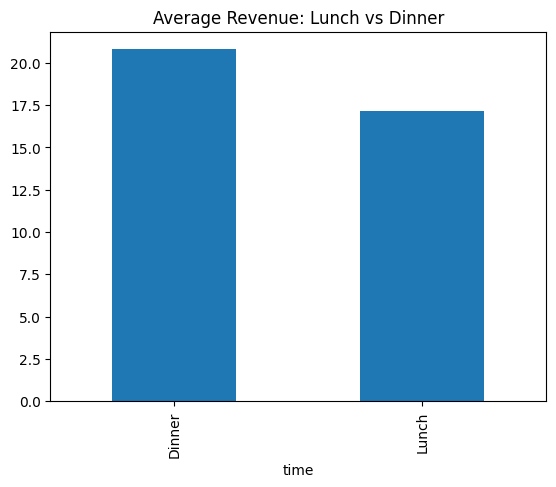

In [109]:
df.groupby('time')['total_bill'].mean().plot(kind='bar')
plt.title("Average Revenue: Lunch vs Dinner")
plt.show()

## Insight
The analysis shows that dinner sessions contribute significantly higher revenue and tips compared to lunch. This suggests increased customer spending and engagement during evening hours.

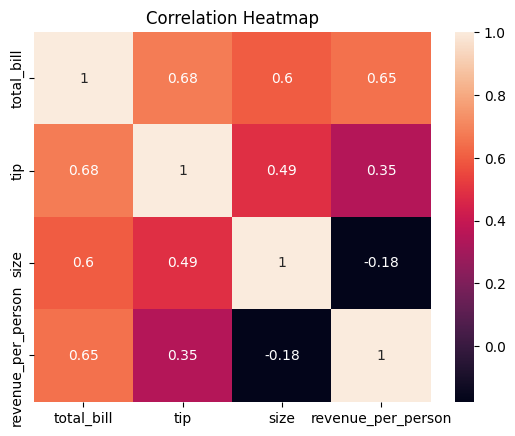

In [110]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.corr(numeric_only=True)

plt.figure()
sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()

## Insight
The heatmap indicates a strong positive correlation between total bill and tip (around 0.8), suggesting that tipping behavior is largely influenced by the total amount spent.

Variables like group size show moderate correlation, indicating some influence on spending patterns, while revenue per person exhibits weaker correlations, suggesting limited direct impact on tipping. Overall, total bill emerges as the most significant factor affecting tips.

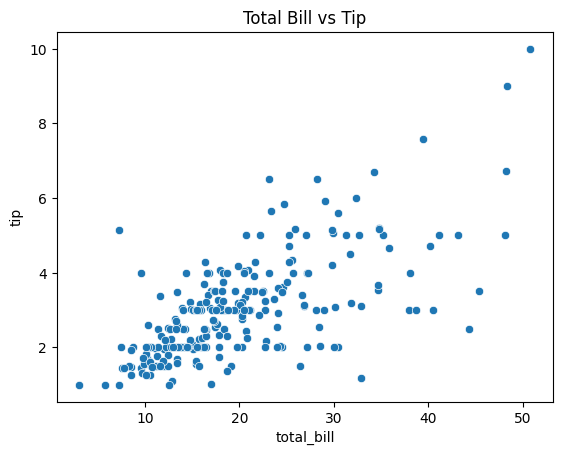

In [111]:
plt.figure()
sns.scatterplot(x='total_bill', y='tip', data=df)
plt.title("Total Bill vs Tip")
plt.show()

## Insight
The scatter plot shows a clear positive relationship between total bill and tip, indicating that customers tend to tip more as their total bill increases. Most data points follow an upward trend, suggesting a consistent pattern in tipping behavior.

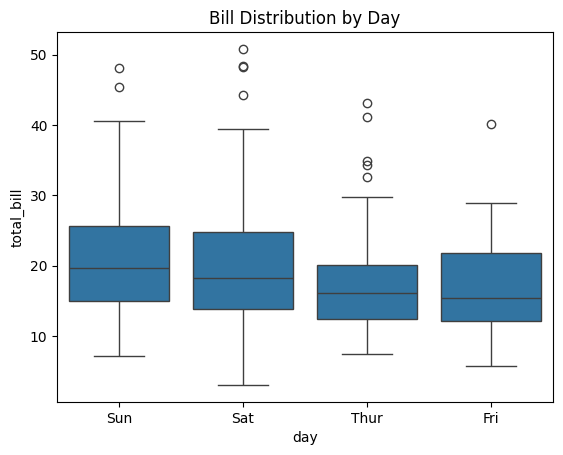

In [112]:
plt.figure()
sns.boxplot(x='day', y='total_bill', data=df)
plt.title("Bill Distribution by Day")
plt.show()

## Insight
The box plot shows that total bill amounts vary across different days of the week, with Sunday having the highest median bill, followed by Saturday, Friday, and Thursday. This indicates that customer spending is highest on weekends.

Additionally, the wider spread on weekends suggests greater variability in spending, and the presence of outliers indicates that some customers spend significantly more than the typical range.

In [113]:
from sklearn.linear_model import LinearRegression

X = df[['total_bill']]
y = df['tip']

model = LinearRegression()
model.fit(X, y)

print("Slope:", model.coef_)
print("Intercept:", model.intercept_)

Slope: [0.10502452]
Intercept: 0.9202696135546731


## Final Insights
- A strong positive relationship exists between total bill and tip, indicating that customer spending directly influences tipping behavior  
- Weekend days, especially Sunday and Saturday, generate higher revenue compared to weekdays  
- Dinner sessions contribute more to total revenue and tips than lunch  
- Male-associated entries show higher average tips, although this may be influenced by other factors like total bill or group size  
- Customer spending and tipping behavior show variability, with some outliers present in the data  

## Business Recommendations
- Increase staffing and resources during weekends to handle higher customer traffic  
- Focus marketing and promotional strategies on dinner hours  
- Introduce offers or discounts for group dining to maximize revenue  
- Maintain consistent service quality to encourage better tipping behavior  

## Conclusion
This analysis highlights key patterns in customer behavior, revenue generation, and tipping trends. By leveraging these insights, businesses can make data-driven decisions to improve service efficiency and maximize revenue.